# Value-Presence Confusion (TP/FP/FN/TN) by Method and Paper

Computes, for each `Study#` paper and each method (Direct LLM / Workflow / MAS), a field-level TP/FP/FN/TN score based on whether the ground truth value is present vs missing compared to the prediction CSV.

Definitions (per field cell): TP=GT present & Pred present; FN=GT present & Pred missing; TN=GT missing & Pred missing; FP=GT missing & Pred present.

In [1]:
import csv
import re
import zipfile
from pathlib import Path
import xml.etree.ElementTree as ET

try:
    from IPython.display import display  # type: ignore
except Exception:  # pragma: no cover
    def display(x):
        print(x)

try:
    import pandas as pd  # type: ignore
except Exception:  # pragma: no cover
    pd = None


def find_repo_root(start: Path | None = None) -> Path:
    p = start or Path.cwd()
    for _ in range(6):
        if (p / "outputs").exists() and (p / "src").exists():
            return p
        p = p.parent
    return start or Path.cwd()


repo_root = find_repo_root()
outputs_root = repo_root / "outputs"
gt_xlsx_path = repo_root / "data" / "wopke_100" / "annotation" / "wopke100.xlsx"

provider_model_tag = "google_gemini-3-1-flash-lite-preview"
n_fields_tag = "42fields"

METHODS = {
    "direct_llm": "direct_llm",
    "workflow": "static_workflow",
    "MAS": "mas",
}


def is_present(v) -> bool:
    if v is None:
        return False
    s = str(v).strip()
    if not s:
        return False
    s_low = s.lower()
    return s_low not in {"nan", "none", "null", "n/a", "na"}


def read_prediction_csv(csv_path: str) -> tuple[list[dict], list[str]]:
    with open(csv_path, "r", encoding="utf-8", errors="ignore", newline="") as f:
        reader = csv.DictReader(f)
        fieldnames = list(reader.fieldnames or [])
        rows = [dict(r) for r in reader]
    return rows, fieldnames


def scan_latest_for_method(method_prefix: str) -> dict[int, str]:
    """Return {paper_id: csv_path} for latest run per paper_id."""
    if not outputs_root.exists():
        raise FileNotFoundError(f"outputs folder not found: {outputs_root}")

    needle = f"{method_prefix}_{provider_model_tag}_{n_fields_tag}_"
    paper_id_re = re.compile(r"^(?P<paper_id>\d+)_")
    date_re = re.compile(r"_(?P<date>\d{4}-\d{2}-\d{2})\.csv$")

    latest_by_pid: dict[int, dict] = {}
    for dated_dir in sorted(outputs_root.iterdir()):
        if not dated_dir.is_dir():
            continue
        if not re.match(r"^\d{4}-\d{2}-\d{2}$", dated_dir.name):
            continue

        for csv_path in dated_dir.glob("*.csv"):
            name = csv_path.name
            if needle not in name:
                continue

            m_pid = paper_id_re.match(name)
            m_date = date_re.search(name)
            if not m_pid or not m_date:
                continue

            pid = int(m_pid.group("paper_id"))
            date = m_date.group("date")

            prev = latest_by_pid.get(pid)
            if prev is None or date > prev["date"]:
                latest_by_pid[pid] = {"date": date, "csv_path": str(csv_path)}

    return {pid: v["csv_path"] for pid, v in latest_by_pid.items()}


def load_ground_truth_by_study_id() -> dict[int, list[dict]]:
    """Load GT XLSX as {Study#: [row_dicts]} using pure-Python XLSX parsing."""
    if not gt_xlsx_path.exists():
        raise FileNotFoundError(f"Ground truth Excel not found: {gt_xlsx_path}")

    with zipfile.ZipFile(gt_xlsx_path, "r") as zf:
        wb_xml = ET.fromstring(zf.read("xl/workbook.xml"))
        rels_xml = ET.fromstring(zf.read("xl/_rels/workbook.xml.rels"))

        rid = None
        for sh in wb_xml.iter():
            if sh.tag.endswith("sheet") and sh.attrib.get("name") == "labels":
                rid = sh.attrib.get("{http://schemas.openxmlformats.org/officeDocument/2006/relationships}id")
                break
        if rid is None:
            raise ValueError("Could not find GT sheet 'labels'")

        target = None
        for rel in rels_xml.iter():
            if rel.tag.endswith("Relationship") and rel.attrib.get("Id") == rid:
                target = rel.attrib.get("Target")
                break
        if target is None:
            raise ValueError(f"Could not find GT relationship for rid={rid}")

        sheet_xml = ET.fromstring(zf.read("xl/" + target))

        shared_strings: list[str] = []
        if "xl/sharedStrings.xml" in zf.namelist():
            ss_root = ET.fromstring(zf.read("xl/sharedStrings.xml"))
            for si in ss_root.findall(".//{*}si"):
                parts = []
                for t in si.findall(".//{*}t"):
                    parts.append(t.text or "")
                shared_strings.append("".join(parts))

        def col_to_index(letters: str) -> int:
            idx = 0
            for ch in letters:
                idx = idx * 26 + (ord(ch) - 64)
            return idx - 1

        def ref_to_col(ref: str) -> int:
            letters = []
            for ch in ref:
                if ch.isalpha():
                    letters.append(ch)
                else:
                    break
            return col_to_index("".join(letters))

        def cell_value(cel):
            t = cel.attrib.get("t")
            v_el = cel.find(".//{*}v")
            if t == "s":
                if v_el is None or v_el.text is None:
                    return ""
                return shared_strings[int(v_el.text)]
            if t == "inlineStr":
                t_el = cel.find(".//{*}t")
                return t_el.text if (t_el is not None and t_el.text is not None) else ""
            if v_el is None or v_el.text is None:
                return None
            return v_el.text

        # Header row is row 1
        header_map: dict[int, object] = {}
        max_col = -1
        for row_el in sheet_xml.iter():
            if not row_el.tag.endswith("row"):
                continue
            r_idx = int(row_el.attrib.get("r", "0"))
            if r_idx != 1:
                continue
            for c_el in row_el:
                if not c_el.tag.endswith("c"):
                    continue
                ref = c_el.attrib.get("r")
                if not ref:
                    continue
                col = ref_to_col(ref)
                header_map[col] = cell_value(c_el)
                max_col = max(max_col, col)

        header_list = [header_map.get(i) for i in range(max_col + 1)]

        # Deduplicate header column names like your loader does
        deduped: list[str] = []
        seen: dict[str, int] = {}
        for col_name in header_list:
            col_name = col_name if col_name is not None else ""
            if col_name in seen:
                seen[col_name] += 1
                deduped.append(f"{col_name}.{seen[col_name]}")
            else:
                seen[col_name] = 0
                deduped.append(col_name)

        gt_by_id: dict[int, list[dict]] = {}
        for row_el in sheet_xml.iter():
            if not row_el.tag.endswith("row"):
                continue
            r_idx = int(row_el.attrib.get("r", "0"))
            if r_idx < 2:
                continue

            rec_values = [None] * (max_col + 1)
            any_non_none = False
            for c_el in row_el:
                if not c_el.tag.endswith("c"):
                    continue
                ref = c_el.attrib.get("r")
                if not ref:
                    continue
                col = ref_to_col(ref)
                val = cell_value(c_el)
                rec_values[col] = val
                if val is not None:
                    any_non_none = True

            if not any_non_none:
                continue

            rec = dict(zip(deduped, rec_values))

            study_key = "Study#" if "Study#" in rec else next((k for k in rec.keys() if k.startswith("Study#")), None)
            if study_key is None:
                continue

            sid_val = rec.get(study_key)
            if sid_val is None:
                continue

            try:
                sid_int = int(float(sid_val))
            except Exception:
                sid_int = int(str(sid_val).strip().split()[0])

            gt_by_id.setdefault(sid_int, []).append(rec)

        return gt_by_id


# Discover latest prediction CSVs per method
pred_by_method: dict[str, dict[int, str]] = {}
for method_label, method_prefix in METHODS.items():
    pred_by_method[method_label] = scan_latest_for_method(method_prefix)
    print(method_label, "papers:", len(pred_by_method[method_label]))

gt_by_id = load_ground_truth_by_study_id()
print("GT papers:", len(gt_by_id))

# Determine canonical prediction fields from any available CSV
any_csv = None
for m in METHODS.keys():
    if pred_by_method[m]:
        any_csv = next(iter(pred_by_method[m].values()))
        break
if any_csv is None:
    raise SystemExit("No matching prediction CSVs found.")

_, canonical_pred_fields = read_prediction_csv(any_csv)

some_pid = next(iter(gt_by_id.keys()))
some_gt_rows = gt_by_id.get(some_pid, [])
gt_keys = set(some_gt_rows[0].keys()) if some_gt_rows else set()
shared_fields = [f for f in canonical_pred_fields if f in gt_keys]
print("canonical_pred_fields:", len(canonical_pred_fields))
print("shared_fields (intersection with GT header):", len(shared_fields))


direct_llm papers: 10
workflow papers: 10
MAS papers: 10
GT papers: 100
canonical_pred_fields: 42
shared_fields (intersection with GT header): 39


,paper_id,method,TP,FP,FN,TN,tp_avg_similarity,precision,recall,specificity,f1
0,1,direct_llm,280,0,32,0,0.457143,1.000000,0.897436,NaN,0.945946
1,1,workflow,280,0,32,0,0.442857,1.000000,0.897436,NaN,0.945946
2,1,MAS,272,0,40,0,0.514706,1.000000,0.871795,NaN,0.931507
3,2,direct_llm,27,113,2,14,0.188889,0.192857,0.931034,0.110236,0.319527
4,2,workflow,17,91,12,36,0.015686,0.157407,0.586207,0.283465,0.248175
5,2,MAS,26,118,3,9,0.250000,0.180556,0.896552,0.070866,0.300578
6,3,direct_llm,37,0,470,0,0.631816,1.000000,0.072978,NaN,0.136029
7,3,workflow,35,0,472,0,0.530476,1.000000,0.069034,NaN,0.129151
8,3,MAS,33,0,474,0,0.729293,1.000000,0.065089,NaN,0.122222
9,4,direct_llm,136,68,0,30,0.519608,0.666667,1.000000,0.306122,0.800000


,paper_id,method,TP,FP,FN,TN,tp_avg_similarity,precision,recall,specificity,f1
23,8,MAS,66,0,2,10,0.626263,1.000000,0.970588,1.000000,0.985075
20,7,MAS,140,0,8,8,0.697619,1.000000,0.945946,1.000000,0.972222
2,1,MAS,272,0,40,0,0.514706,1.000000,0.871795,NaN,0.931507
29,10,MAS,240,40,32,0,0.868056,0.857143,0.882353,0.000000,0.869565
11,4,MAS,136,68,0,30,0.534314,0.666667,1.000000,0.306122,0.800000
14,5,MAS,102,66,0,27,0.421569,0.607143,1.000000,0.290323,0.755556
26,9,MAS,117,78,0,0,0.219658,0.600000,1.000000,0.000000,0.750000
17,6,MAS,36,36,3,3,0.143519,0.500000,0.923077,0.076923,0.648649
5,2,MAS,26,118,3,9,0.250000,0.180556,0.896552,0.070866,0.300578
8,3,MAS,33,0,474,0,0.729293,1.000000,0.065089,NaN,0.122222


rows: 30
paper_ids: 10 methods: 3
Paper label mapping (short label -> full author/title):


,paper_id,short_label,author_full,title_full
0,1,Jensen,"Jensen, ES","Grain yield, symbiotic N-2 fixation and inters..."
1,2,Hauggaard-Nielsen,"Hauggaard-Nielsen, H; Ambus, P; Jensen, ES","Interspecific competition, N use and interfere..."
2,3,Bulson,"Bulson, HAJ; Snaydon, RW; Stopes, CE",Effects of plant density on intercropped wheat...
3,4,Li,"Li, L; Sun, JH; Zhang, FS; Li, XL; Yang, SC; R...",Wheat/maize or wheat/soybean strip intercroppi...
4,5,Li,"Li, L; Yang, SC; Li, XL; Zhang, FS; Christie, P",Interspecific complementary and competitive in...
5,6,Hauggaard-Nielsen,"Hauggaard-Nielsen, H; Ambus, P; Jensen, ES",The comparison of nitrogen use and leaching in...
6,7,Hauggaard-Nielsen,"Hauggaard-Nielsen, H; Jensen, ES",Evaluating pea and barley cultivars for comple...
7,8,Li,"Li, L; Sun, JH; Zhang, FS; Guo, TW; Bao, XG; S...",Root distribution and interactions between int...
8,9,Ghosh,"Ghosh, PK","Growth, yield, competition and economics of gr..."
9,10,Dhima,"Dhima, K. V.; Lithourgidis, A. S.; Vasilakoglo...",Competition indices of common vetch and cereal...


Could not write to /output/imgs; saving to /home/com3dian/Github/meta_analysis_agents/output/imgs


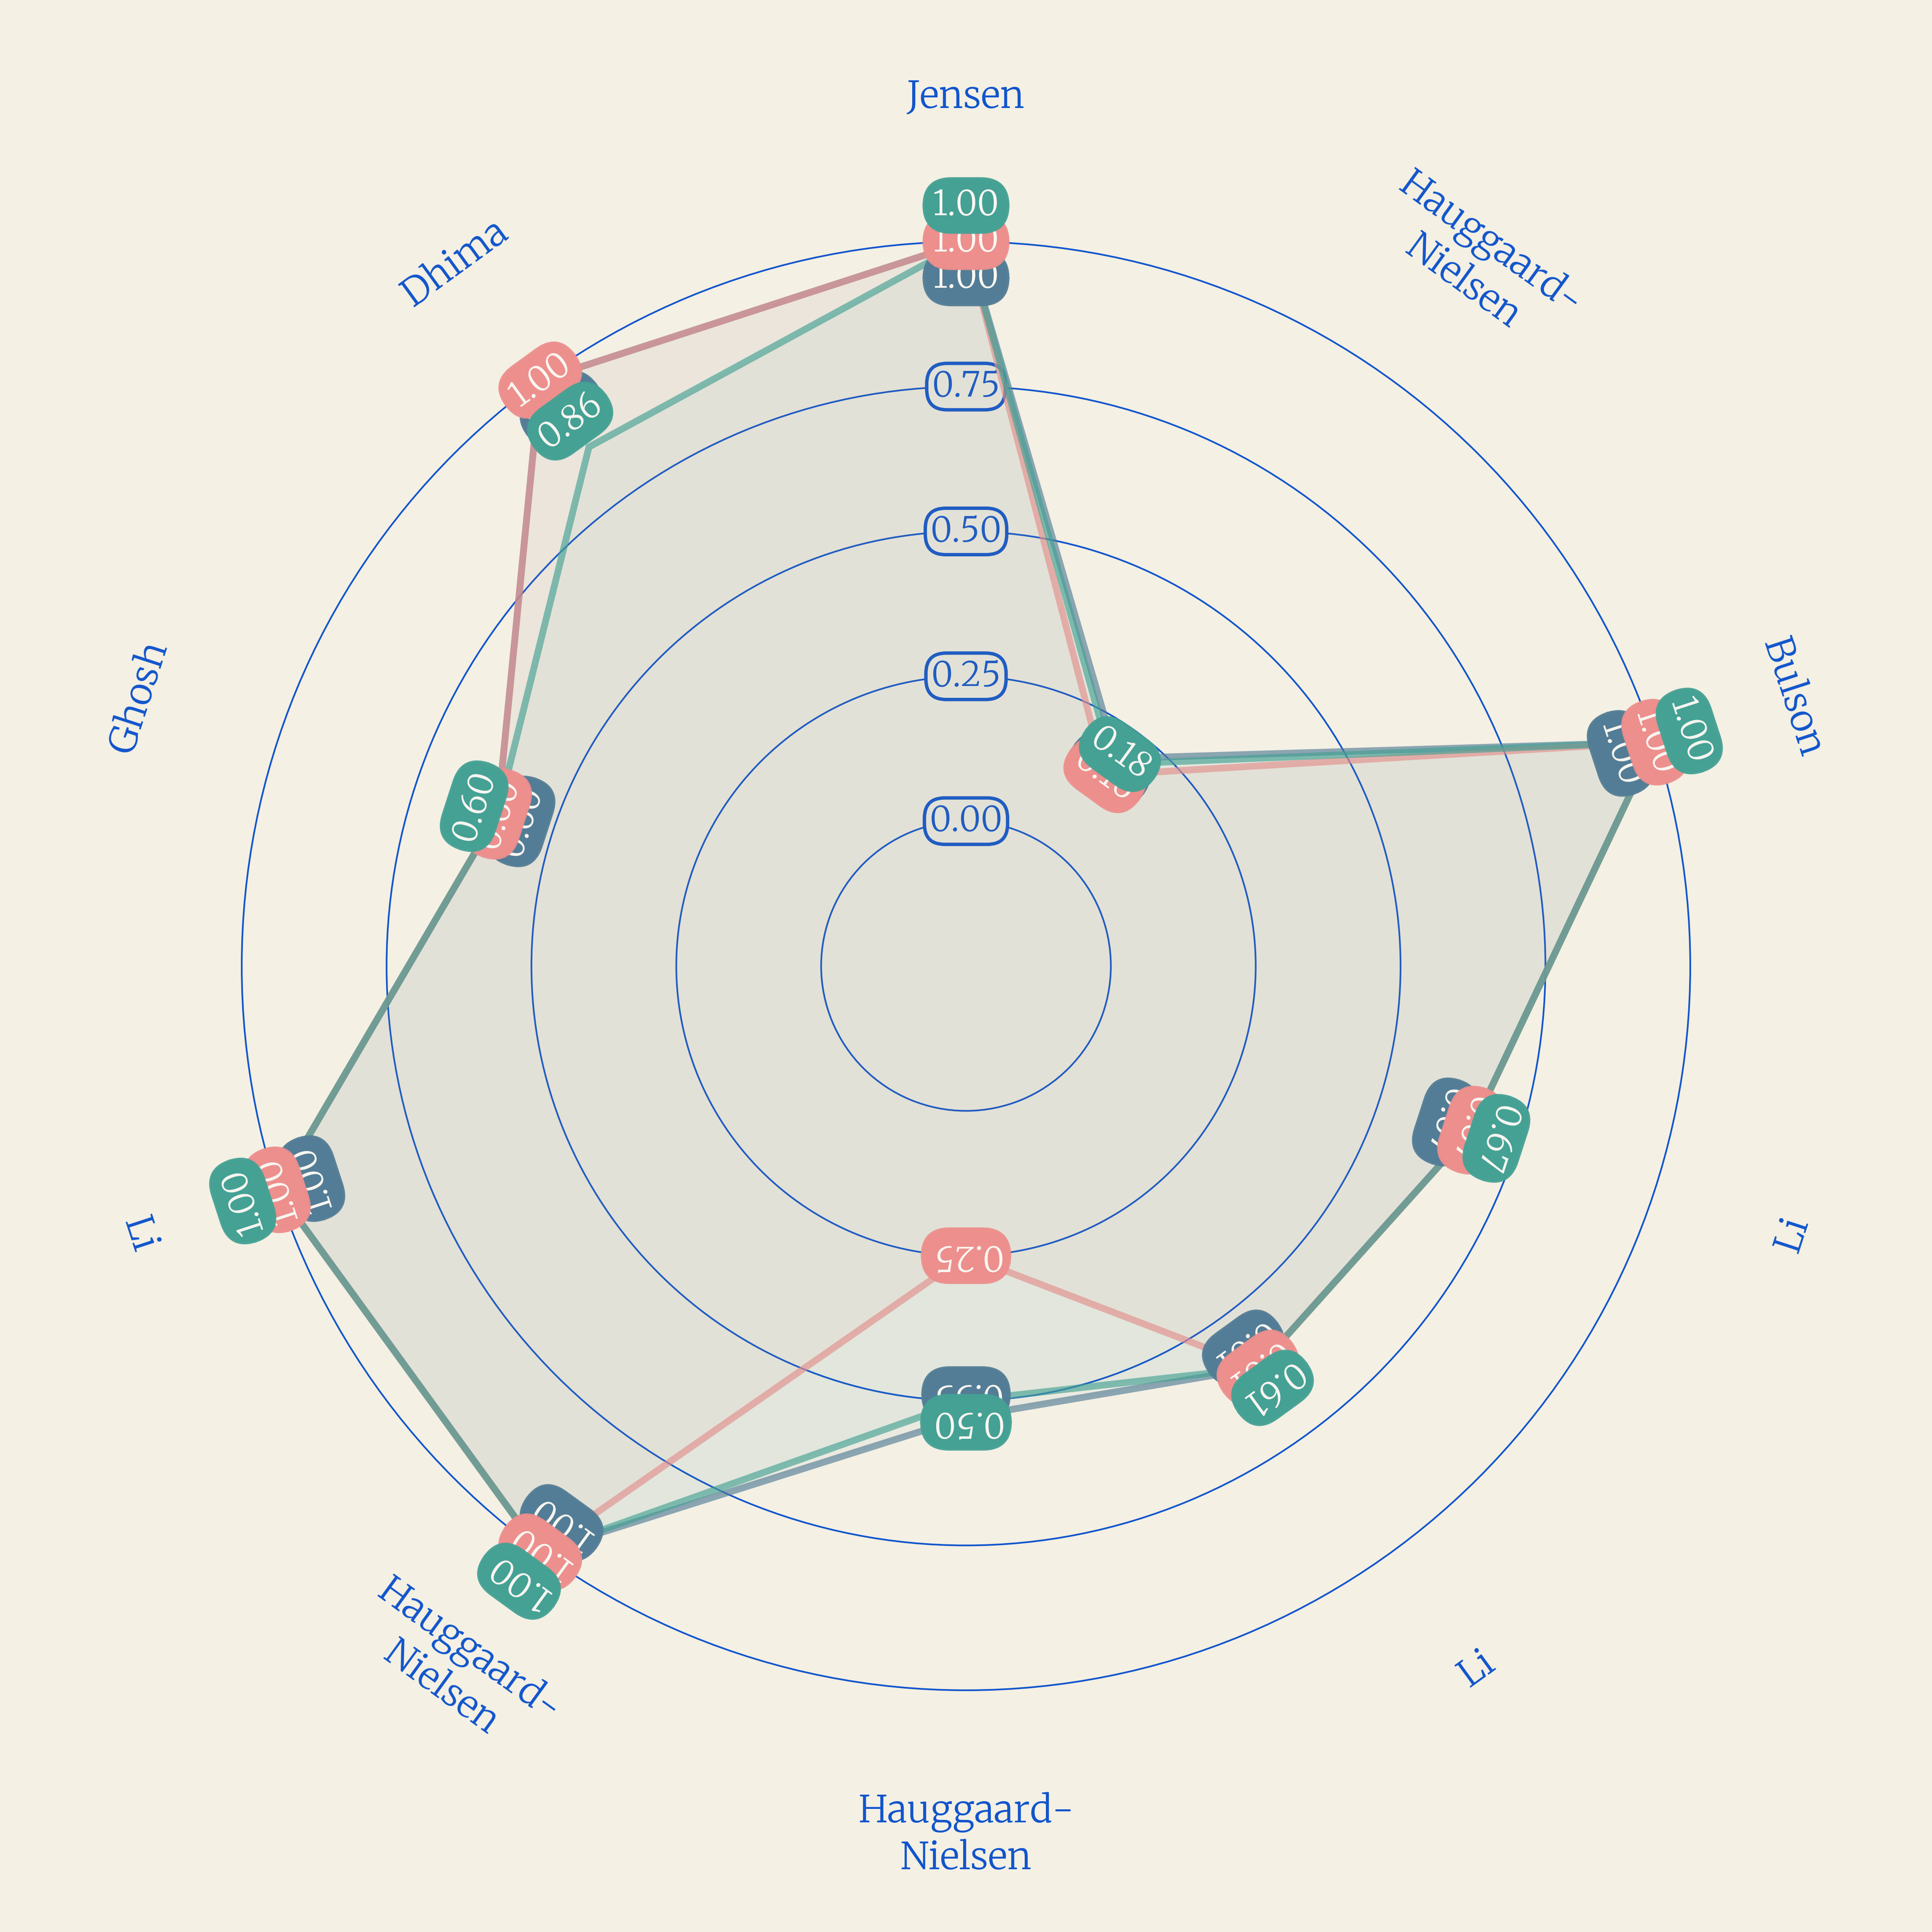

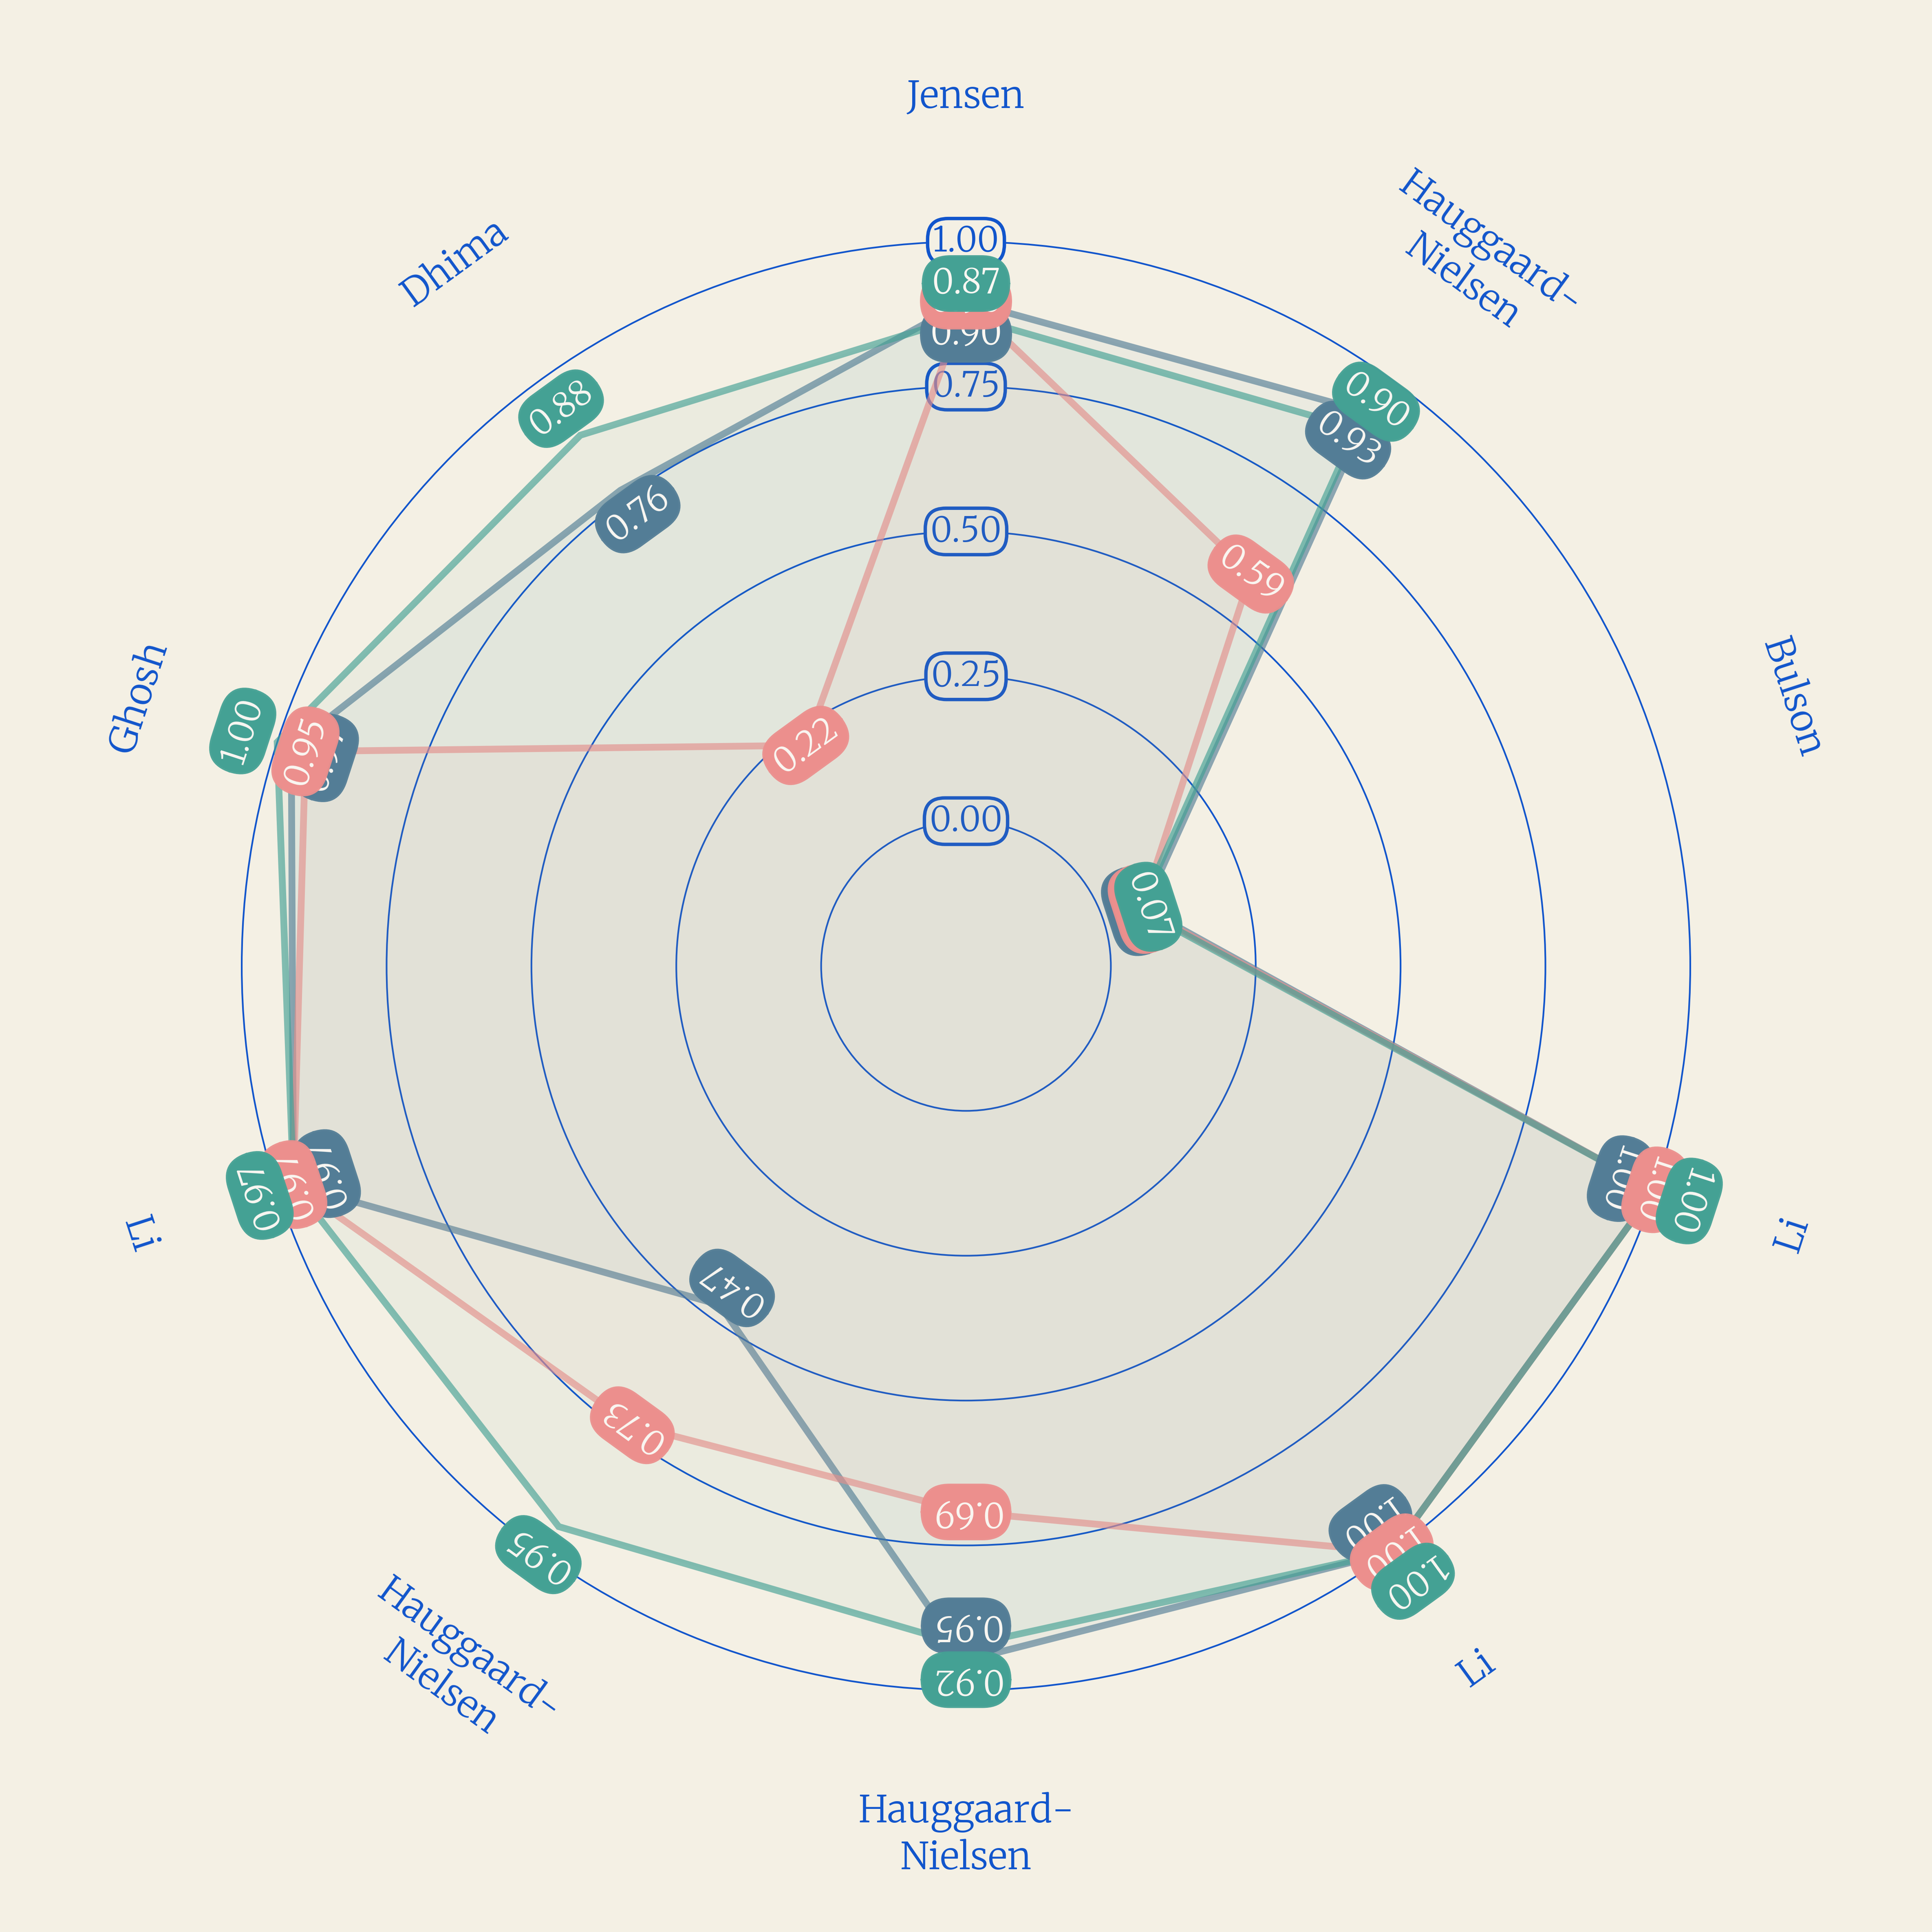

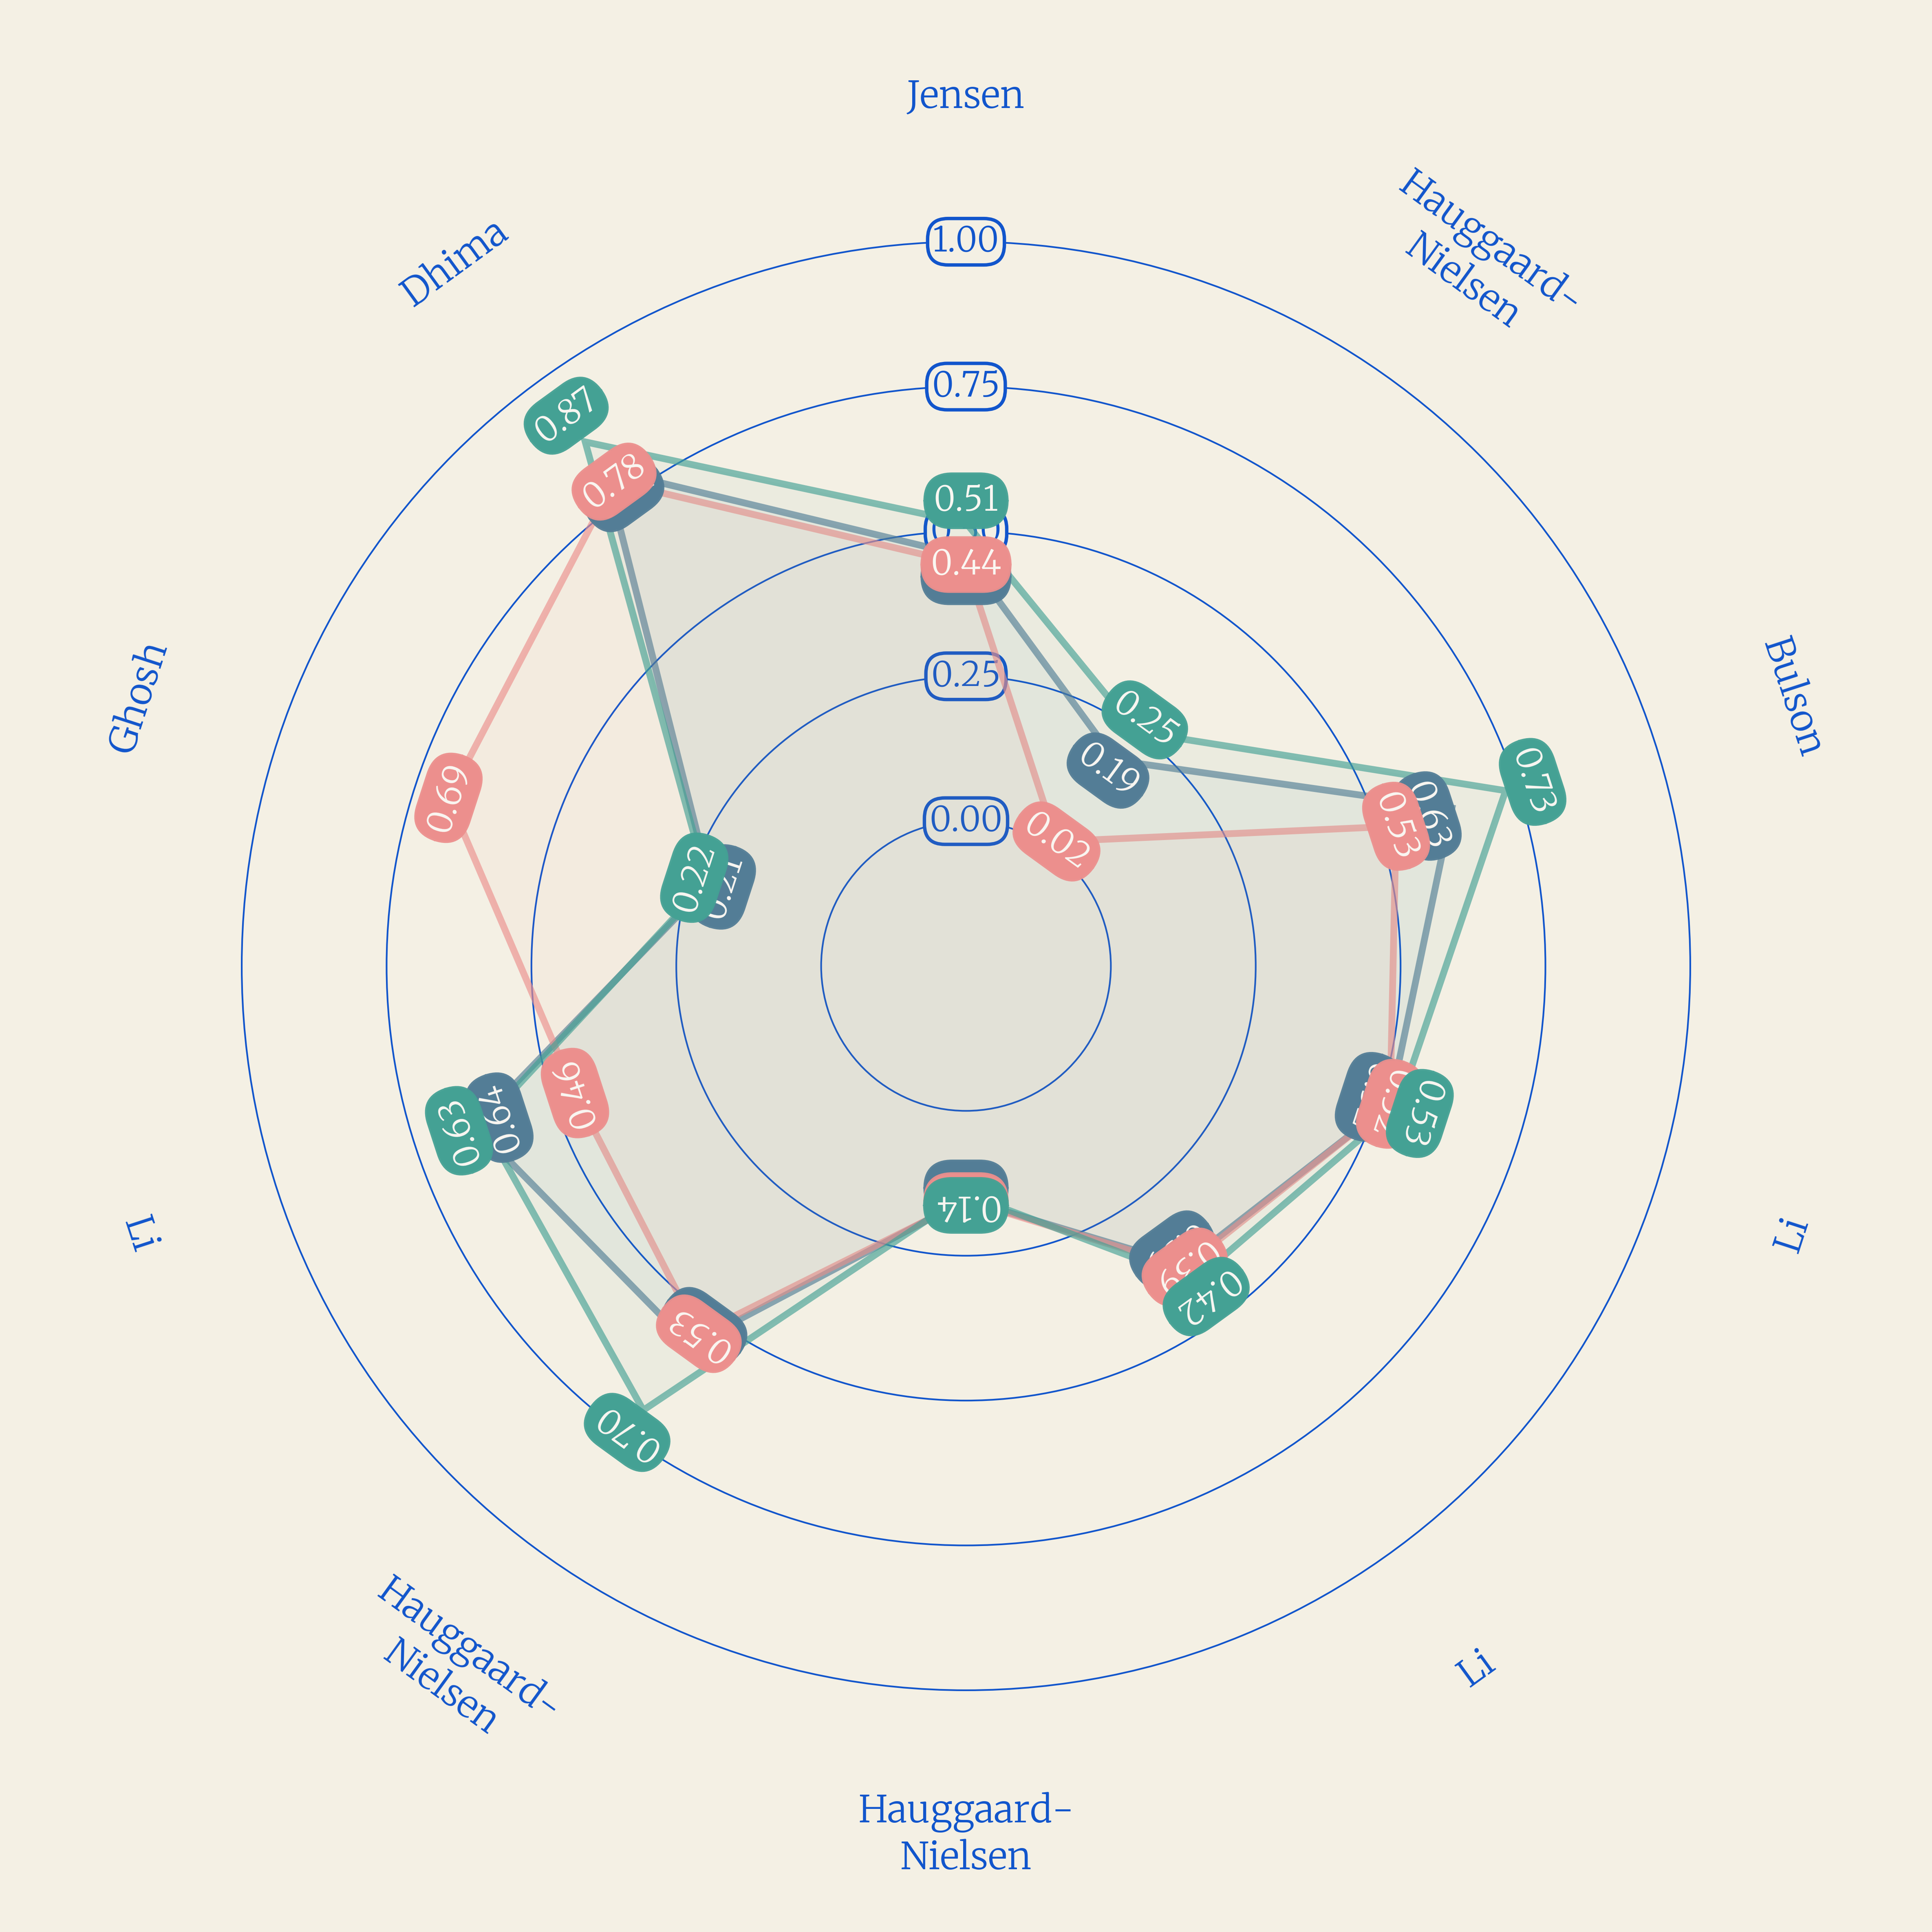

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
# Point directly to the font file in your folder
font_path ='/home/com3dian/Downloads/Merriweather/Merriweather-VariableFont_opsz,wdth,wght.ttf'
font_manager.fontManager.addfont(font_path)
# Now you can use it
plt.rcParams['font.family'] = 'Merriweather'


def confusion_counts(pred_rows: list[dict], gt_rows: list[dict], fields: list[str]) -> dict:
    # Greedy one-to-one row matching (swap-aware) followed by cell-level TP/FP/FN/TN.
    # This avoids the positional row alignment used previously.
    conf = {"TP": 0, "FP": 0, "FN": 0, "TN": 0}
    tp_similarity_total = 0.0
    tp_similarity_n = 0

    def _normalize_label(v: object) -> str:
        return str(v).strip().lower()

    def _find_crop_swap_pairs(cols: list[str]) -> list[tuple[str, str]]:
        col_set = set(cols)
        seen: set[str] = set()
        pairs: list[tuple[str, str]] = []
        for c in cols:
            if c in seen:
                continue
            for suffix1, suffix2 in [(" 1", " 2"), ("1", "2")]:
                if c.endswith(suffix1):
                    partner = c[: -len(suffix1)] + suffix2
                    if partner in col_set:
                        pairs.append((c, partner))
                        seen.add(c)
                        seen.add(partner)
                        break
        return pairs

    def _apply_swaps(row: dict, pairs: list[tuple[str, str]]) -> dict:
        if not pairs:
            return row
        out = dict(row)
        for c1, c2 in pairs:
            out[c1] = row.get(c2, None)
            out[c2] = row.get(c1, None)
        return out

    def _is_label_field(col: str) -> bool:
        lc = col.lower()
        # Heuristic: use crop species / crop label-like columns for stricter match scoring.
        return ("species" in lc) or ("label" in lc)

    def _field_similarity(col: str, ext_val: object, gt_val: object) -> float:
        # Similarity used only for greedy pairing. Missing/missing gives 0.0
        # so jointly-missing fields do not create a free match.
        ext_p = is_present(ext_val)
        gt_p = is_present(gt_val)
        if not ext_p or not gt_p:
            return 0.0
        if _is_label_field(col):
            return 1.0 if _normalize_label(ext_val) == _normalize_label(gt_val) else 0.0
        # For non-label fields, treat any jointly-present value as a match signal.
        return 1.0

    swap_pairs = _find_crop_swap_pairs(fields)

    def _pair_scores(ext_row: dict, gt_row: dict) -> tuple[float, bool]:
        # Returns (mean_score, swapped_orientation_used)
        def score_orientation(row_values: dict) -> float:
            if not fields:
                return 0.0
            s = 0.0
            for c in fields:
                s += _field_similarity(c, row_values.get(c), gt_row.get(c))
            return s / len(fields)

        mean_orig = score_orientation(ext_row)
        if not swap_pairs:
            return mean_orig, False

        ext_swapped = _apply_swaps(ext_row, swap_pairs)
        mean_swap = score_orientation(ext_swapped)
        return (mean_swap, True) if mean_swap > mean_orig else (mean_orig, False)

    # --- Similarity for TP cell averaging (evaluate_3-compatible) ---
    # Ported from `src/experimentutils/eval_utils.py::field_similarity_score`
    # but implemented without pandas.
    import decimal
    from datetime import date, timedelta

    _MISSING_TOKENS = {"", "nan", "none", "null", "n/a", "na"}
    _YEAR_RE = re.compile(r"\b(1\d{3}|20\d{2})\b")
    _PURE_NUMBER_RE = re.compile(r"^[+-]?[\d,]+\.?\d*$")
    _SCIENTIFIC_NAME_RE = re.compile(r"\s*\([A-Z][a-z]+(?:\s+[a-z]+\.?)+\)")

    def _is_missing(v: object) -> bool:
        if v is None:
            return True
        return str(v).strip().lower() in _MISSING_TOKENS

    def _try_parse_decimal(v: object) -> object:
        s = str(v).strip().replace(",", "")
        if not _PURE_NUMBER_RE.match(s):
            return None
        try:
            return decimal.Decimal(s)
        except (decimal.InvalidOperation, ValueError):
            return None

    def _remove_decimal_point_numeric_string(v: object) -> str | None:
        s = str(v).strip().replace(",", "")
        if not _PURE_NUMBER_RE.match(s):
            return None
        return s.replace(".", "")

    def _excel_serial_to_iso(v: object) -> str | None:
        s = str(v).strip().replace(",", "")
        if not _PURE_NUMBER_RE.match(s):
            return None
        try:
            dec = decimal.Decimal(s)
        except (decimal.InvalidOperation, ValueError):
            return None
        try:
            n = int(dec)
        except (OverflowError, ValueError):
            return None
        if n < 20000 or n > 60000:
            return None
        base = date(1900, 1, 1)
        d = base + timedelta(days=n - 2)
        return d.isoformat()

    def _normalize_text(v: object) -> str:
        cleaned = _SCIENTIFIC_NAME_RE.sub("", str(v))
        return " ".join(cleaned.lower().split())

    def _soft_tokens_match(t1: str, t2: str) -> bool:
        return t1 == t2 or t1.startswith(t2) or t2.startswith(t1)

    def _extract_year(v: object) -> str | None:
        m = _YEAR_RE.search(str(v))
        return m.group(1) if m else None

    def field_similarity_score(ref_val: object, hyp_val: object) -> float:
        if _is_missing(ref_val) or _is_missing(hyp_val):
            return 0.0

        # 1) Numeric comparison
        ref_dec = _try_parse_decimal(ref_val)
        hyp_dec = _try_parse_decimal(hyp_val)
        if ref_dec is not None and hyp_dec is not None:
            if ref_dec == hyp_dec:
                return 1.0
            ref_no_dot = _remove_decimal_point_numeric_string(ref_val)
            hyp_no_dot = _remove_decimal_point_numeric_string(hyp_val)
            if ref_no_dot is not None and hyp_no_dot is not None and ref_no_dot == hyp_no_dot:
                return 0.5
            return 0.0

        # 2) Excel serial date comparison
        ref_excel = _excel_serial_to_iso(ref_val)
        hyp_excel = _excel_serial_to_iso(hyp_val)
        if ref_excel is not None or hyp_excel is not None:
            def _normalize_dateish(x: object) -> str | None:
                s = str(x).strip()
                if re.match(r"^\d{4}-\d{2}-\d{2}$", s):
                    return s
                return _excel_serial_to_iso(s)

            ref_iso = ref_excel or _normalize_dateish(ref_val)
            hyp_iso = hyp_excel or _normalize_dateish(hyp_val)
            if ref_iso is not None and hyp_iso is not None:
                return 1.0 if ref_iso == hyp_iso else 0.0

        # 3) Year comparison
        ref_year = _extract_year(ref_val)
        hyp_year = _extract_year(hyp_val)
        if ref_year is not None and hyp_year is not None:
            return 1.0 if ref_year == hyp_year else 0.0

        # 4) Text categorical comparison (ROUGE-L F1 via soft LCS)
        ref_tokens = _normalize_text(ref_val).split()
        hyp_tokens = _normalize_text(hyp_val).split()
        if not ref_tokens or not hyp_tokens:
            return 0.0

        m, nl = len(ref_tokens), len(hyp_tokens)
        dp = [[0] * (nl + 1) for _ in range(m + 1)]
        for i in range(1, m + 1):
            for j in range(1, nl + 1):
                if _soft_tokens_match(ref_tokens[i - 1], hyp_tokens[j - 1]):
                    dp[i][j] = dp[i - 1][j - 1] + 1
                else:
                    dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

        lcs = dp[m][nl]
        p = lcs / nl
        r = lcs / m
        return 0.0 if p + r == 0 else 2 * p * r / (p + r)

    # Greedy matching over all candidate pairs, sorted by mean similarity.
    candidates: list[tuple[float, int, int, bool]] = []
    for ext_i, ext_row in enumerate(pred_rows):
        for gt_i, gt_row in enumerate(gt_rows):
            mean_score, swapped = _pair_scores(ext_row, gt_row)
            candidates.append((mean_score, ext_i, gt_i, swapped))

    candidates.sort(key=lambda x: x[0], reverse=True)
    used_ext: set[int] = set()
    used_gt: set[int] = set()
    matches: list[tuple[int, int, bool]] = []
    for mean_score, ext_i, gt_i, swapped in candidates:
        if ext_i in used_ext or gt_i in used_gt:
            continue
        used_ext.add(ext_i)
        used_gt.add(gt_i)
        matches.append((ext_i, gt_i, swapped))

    # Matched pairs: compare fields cell-by-cell.
    for ext_i, gt_i, swapped in matches:
        gt_row = gt_rows[gt_i]
        ext_row = pred_rows[ext_i]
        ext_row_adj = _apply_swaps(ext_row, swap_pairs) if swapped else ext_row
        for f in fields:
            gt_p = is_present(gt_row.get(f))
            pred_p = is_present(ext_row_adj.get(f))
            if gt_p and pred_p:
                conf["TP"] += 1
                tp_similarity_total += field_similarity_score(gt_row.get(f), ext_row_adj.get(f))
                tp_similarity_n += 1
            elif gt_p and not pred_p:
                conf["FN"] += 1
            elif (not gt_p) and pred_p:
                conf["FP"] += 1
            else:
                conf["TN"] += 1

    # Unmatched GT rows compare against an empty prediction row.
    for gt_i, gt_row in enumerate(gt_rows):
        if gt_i in used_gt:
            continue
        for f in fields:
            gt_p = is_present(gt_row.get(f))
            if gt_p:
                conf["FN"] += 1
            else:
                conf["TN"] += 1

    # Unmatched extracted rows compare against an empty GT row.
    for ext_i, ext_row in enumerate(pred_rows):
        if ext_i in used_ext:
            continue
        for f in fields:
            pred_p = is_present(ext_row.get(f))
            if pred_p:
                conf["FP"] += 1
            else:
                conf["TN"] += 1

    conf["tp_avg_similarity"] = (tp_similarity_total / tp_similarity_n) if tp_similarity_n else float("nan")
    return conf


# Only evaluate paper_ids that have at least one prediction CSV (across methods).
paper_ids = sorted(set().union(*(set(pred_by_method[m].keys()) for m in METHODS.keys())))
results = []

for pid in paper_ids:
    gt_rows = gt_by_id.get(pid, [])
    for method_label in METHODS.keys():
        csv_path = pred_by_method[method_label].get(pid)
        if csv_path is None:
            pred_rows = []
        else:
            pred_rows, _ = read_prediction_csv(csv_path)

        conf = confusion_counts(pred_rows, gt_rows, shared_fields)
        TP, FP, FN, TN = conf["TP"], conf["FP"], conf["FN"], conf["TN"]
        precision = TP / (TP + FP) if (TP + FP) else float("nan")
        recall = TP / (TP + FN) if (TP + FN) else float("nan")
        specificity = TN / (TN + FP) if (TN + FP) else float("nan")
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else float("nan")

        results.append(
            {
                "paper_id": pid,
                "method": method_label,
                **conf,
                "precision": precision,
                "recall": recall,
                "specificity": specificity,
                "f1": f1,
            }
        )

if pd is not None:
    df = pd.DataFrame(results)
    display(df.head(15))
    display(df.sort_values(["method", "f1"], ascending=[True, False]).groupby("method").head(10))
else:
    display(results[:15])

print("rows:", len(results))
print("paper_ids:", len(paper_ids), "methods:", len(METHODS))

# --- Plot metrics as grouped bars (one figure, two subplots) ---
try:
    import numpy as np
except Exception:  # pragma: no cover
    np = None

try:
    import matplotlib.pyplot as plt
except Exception:  # pragma: no cover
    plt = None

methods_order = ["direct_llm", "workflow", "MAS"]
paper_ids_sorted = sorted({r["paper_id"] for r in results})

def _paper_label(pid: int) -> str:
    # Use an author/title-derived label instead of numeric paper_id.
    # GT is loaded as `gt_by_id: {Study#: [row_dicts...]}`.
    rows = gt_by_id.get(pid, [])
    if not rows:
        return str(pid)
    rec = rows[0]

    author = rec.get("Author")
    if isinstance(author, str) and author.strip():
        a = author.strip()
        # Many rows look like: "Jensen, ES". Prefer the last name before the comma.
        if "," in a:
            a = a.split(",", 1)[0].strip()
        # Keep only the first word token.
        a = a.split()[0].strip() if a.split() else a
        return a or str(pid)

    title = rec.get("Title")
    if isinstance(title, str) and title.strip():
        t = title.strip().split()[0].strip()
        return t or str(pid)

    return str(pid)

def _paper_author_full(pid: int) -> str:
    rows = gt_by_id.get(pid, [])
    if not rows:
        return ""
    rec = rows[0]
    author = rec.get("Author")
    return author.strip() if isinstance(author, str) else ""

def _paper_title_full(pid: int) -> str:
    rows = gt_by_id.get(pid, [])
    if not rows:
        return ""
    rec = rows[0]
    title = rec.get("Title")
    return title.strip() if isinstance(title, str) else ""

paper_labels_sorted = [_paper_label(pid) for pid in paper_ids_sorted]

# Print mapping so similar short labels can be traced to full paper names.
paper_name_rows = []
for pid, short_label in zip(paper_ids_sorted, paper_labels_sorted):
    paper_name_rows.append({
        "paper_id": pid,
        "short_label": short_label,
        "author_full": _paper_author_full(pid),
        "title_full": _paper_title_full(pid),
    })

print("Paper label mapping (short label -> full author/title):")
if pd is not None:
    display(pd.DataFrame(paper_name_rows))
else:
    for r in paper_name_rows:
        print(f"{r['paper_id']:>3} | {r['short_label']:<15} | {r['author_full']} | {r['title_full']}")

def metric_fp_rate(r: dict) -> float:
    # Interpreting the user request as precision: TP / (FP + TP)
    denom = r["FP"] + r["TP"]
    return (r["TP"] / denom) if denom else float("nan")

def metric_recall(r: dict) -> float:
    denom = r["TP"] + r["FN"]
    return (r["TP"] / denom) if denom else float("nan")

def metric_tp_avg_similarity(r: dict) -> float:
    return r.get("tp_avg_similarity", float("nan"))

# Index results by (paper_id, method) for fast lookup
by_key = {(r["paper_id"], r["method"]): r for r in results}

if plt is None or np is None:
    # Fallback: print a compact preview
    if not paper_ids_sorted:
        print("No prediction CSVs discovered; nothing to plot.")
    else:
        for m in methods_order:
            row0 = by_key.get((paper_ids_sorted[0], m))
            if row0:
                print(m, "sample TP/(FP+TP)=", metric_fp_rate(row0), "TP/(TP+FN)=", metric_recall(row0), "avg TP similarity=", metric_tp_avg_similarity(row0))
else:
    x = np.arange(len(paper_ids_sorted))
    width = 0.26 if len(methods_order) <= 3 else 0.18

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(26, 6.2), constrained_layout=True)
    fig.set_dpi(600)
    from matplotlib.patches import FancyBboxPatch

    # Keep bar colors identical to radar colors.
    radar_colors = {
        "direct_llm": "#537d96",
        "workflow": "#ec8f8d",
        "MAS": "#44a194",
    }

    # Rounded-bar tuning (increase for more rounded/capsule-like tops).
    bar_corner_rounding = 0.03

    def _round_bar_container(ax, bar_container, rounding_size: float):
        for rect in bar_container.patches:
            h = rect.get_height()
            if not np.isfinite(h) or h <= 0:
                continue
            x0, y0 = rect.get_x(), rect.get_y()
            w = rect.get_width()
            fc = rect.get_facecolor()
            z = rect.get_zorder()
            rect.set_visible(False)
            rounded = FancyBboxPatch(
                (x0, y0),
                w,
                h,
                boxstyle=f'round,pad=0,rounding_size={rounding_size}',
                linewidth=0,
                facecolor=fc,
                edgecolor='none',
                zorder=z,
                mutation_aspect=1,
            )
            ax.add_patch(rounded)

    # Export figures
    imgs_dir = Path('/output/imgs')
    try:
        imgs_dir.mkdir(parents=True, exist_ok=True)
    except Exception:
        imgs_dir = repo_root / 'output' / 'imgs'
        imgs_dir.mkdir(parents=True, exist_ok=True)
        print(f'Could not write to /output/imgs; saving to {imgs_dir}')

    for j, m in enumerate(methods_order):
        offsets = (j - (len(methods_order) - 1) / 2) * width
        fpr_vals = []
        rec_vals = []
        tp_sim_vals = []
        for pid in paper_ids_sorted:
            r = by_key.get((pid, m))
            if r is None:
                fpr_vals.append(float("nan"))
                rec_vals.append(float("nan"))
                tp_sim_vals.append(float("nan"))
            else:
                fpr_vals.append(metric_fp_rate(r))
                rec_vals.append(metric_recall(r))
                tp_sim_vals.append(metric_tp_avg_similarity(r))

        method_color = radar_colors.get(m, '#333333')
        bars1 = ax1.bar(x + offsets, fpr_vals, width=width, label=m, alpha=0.9, color=method_color)
        bars2 = ax2.bar(x + offsets, rec_vals, width=width, label=m, alpha=0.9, color=method_color)
        bars3 = ax3.bar(x + offsets, tp_sim_vals, width=width, label=m, alpha=0.9, color=method_color)
        _round_bar_container(ax1, bars1, bar_corner_rounding)
        _round_bar_container(ax2, bars2, bar_corner_rounding)
        _round_bar_container(ax3, bars3, bar_corner_rounding)

    radar_alpha = 0.95
    ax1.set_xlabel("paper")
    ax1.set_ylabel("value")
    ax1.set_xticks(x)
    ax1.set_xticklabels(paper_labels_sorted, rotation=45, ha="right")
    ax1.set_ylim(0, 1)
    ax1.grid(True, axis="y", alpha=radar_alpha)

    ax2.set_xlabel("paper")
    ax2.set_ylabel("value")
    ax2.set_xticks(x)
    ax2.set_xticklabels(paper_labels_sorted, rotation=45, ha="right")
    ax2.set_ylim(0, 1)
    ax2.grid(True, axis="y", alpha=radar_alpha)

    ax3.set_xlabel("paper")
    ax3.set_ylabel("similarity")
    ax3.set_xticks(x)
    ax3.set_xticklabels(paper_labels_sorted, rotation=45, ha="right")
    ax3.set_ylim(0, 1)
    ax3.grid(True, axis="y", alpha=radar_alpha)

    # Metric names under each bar subplot.
    ax1.text(0.5, -0.42, 'Precision (TP/(FP+TP))', transform=ax1.transAxes, ha='center', va='top', fontsize=11, weight='bold')
    ax2.text(0.5, -0.42, 'Recall (TP/(TP+FN))', transform=ax2.transAxes, ha='center', va='top', fontsize=11, weight='bold')
    ax3.text(0.5, -0.42, 'Avg similarity on TP cells', transform=ax3.transAxes, ha='center', va='top', fontsize=11, weight='bold')

    legend_handles = [
        plt.Line2D([0], [0], marker='s', linestyle='None', markersize=12,
                   markerfacecolor=radar_colors[m], markeredgecolor=radar_colors[m], label=m)
        for m in methods_order
    ]
    legend = fig.legend(
        handles=legend_handles,
        title="method",
        loc="upper right",
        bbox_to_anchor=(0.99, 0.99),
        frameon=False,
    )
    legend.get_title().set_color('#222222')
    for text, m in zip(legend.get_texts(), methods_order):
        text.set_color(radar_colors.get(m, '#222222'))
    bar_out_path = imgs_dir / 'value_presence_grouped_bars.png'
    fig.savefig(bar_out_path, dpi=fig.dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

    # --- Radar plots for the three metrics (one figure per metric) ---

    def _metric_at(pid: int, method: str, fn):
        r = by_key.get((pid, method))
        return float("nan") if r is None else fn(r)

    def _plot_radar(metric_name: str, metric_fn, rlabel: str):
        # mplsoccer Radar (match `radar_pot.ipynb` styling).
        from mplsoccer import Radar

        pull_factors_by_method = {'direct_llm': 0.95, 'workflow': 1.00, 'MAS': 1.05}

        params = paper_labels_sorted
        lower_bounds = [0.0] * len(params)
        upper_bounds = [1.0] * len(params)

        radar = Radar(
            params,
            lower_bounds,
            upper_bounds,
            round_int=[False] * len(params),
            num_rings=4,
            ring_width=1,
            center_circle_radius=1,
        )

        # Background rings style (edit these constants as desired).
        bg_ring_edgecolor = '#595959'
        bg_ring_lw = 0.5

        # Figure underlay/background (whole image canvas)
        fig_bg_color = "#f4f0e4"

        # Make axis background transparent so the figure underlay shows through.
        fig_r, ax_r = radar.setup_axis(facecolor='none')
        fig_r.set_size_inches(10, 10)
        fig_r.set_dpi(600)
        fig_r.patch.set_facecolor(fig_bg_color)
        fig_r.patch.set_alpha(1.0)

        # Capsule label styling (edit these constants as desired).
        capsule_text_color = '#f4f0e4'
        capsule_fill_alpha = 1
        capsule_edge_alpha = 0.95

        rings_inner = radar.draw_circles(ax=ax_r, facecolor='none', edgecolor=bg_ring_edgecolor, lw=bg_ring_lw)
        # Ensure the ring scale labels render above the ring circles.
        try:
            rings_inner.set_zorder(0)
        except Exception:
            try:
                for _a in rings_inner:
                    try:
                        _a.set_zorder(0)
                    except Exception:
                        pass
            except Exception:
                pass
        radar.draw_param_labels(ax=ax_r, fontsize=11, color=bg_ring_edgecolor)

        # Ring/range labels on the rings along one radius (same vertex logic as value capsules).
        ring_values = [0.00, 0.25, 0.50, 0.75, 1.00]
        ring_axis_idx = 0  # which radius to place the 5 labels on
        for rv in ring_values:
            _, ring_vertices = radar.draw_radar_solid(
                [rv] * len(params),
                ax=ax_r,
                kwargs={'facecolor': 'none', 'edgecolor': 'none', 'lw': 0},
            )
            x_r = ring_vertices[ring_axis_idx, 0]
            y_r = ring_vertices[ring_axis_idx, 1]
            angle_deg = np.degrees(np.arctan2(y_r, x_r))
            rotation_angle = angle_deg - 90
            ax_r.text(
                x_r,
                y_r,
                f"{rv:.2f}",
                ha='center',
                va='center',
                rotation=rotation_angle,  # toward center along chosen radius
                color=bg_ring_edgecolor,
                fontsize=10,
                weight='bold',
                zorder=2,
                bbox=dict(
                    facecolor=fig_bg_color,
                    edgecolor=bg_ring_edgecolor,
                    boxstyle='round,pad=0.15,rounding_size=0.6',
                    alpha=1.0,
                ),
            )

        for m in methods_order:
            method_color = radar_colors.get(m, '#333333')
            pull_factor = pull_factors_by_method.get(m, 1.05)
            # Use RGBA so we can control polygon edge vs fill opacity separately.
            from matplotlib.colors import to_rgb
            rgb = to_rgb(method_color)
            face_rgba = (rgb[0], rgb[1], rgb[2], 0.05)
            edge_rgba = (rgb[0], rgb[1], rgb[2], 0.65)

            vals = [_metric_at(pid, m, metric_fn) for pid in paper_ids_sorted]
            # Replace NaNs with 0 so the polygon still draws.
            vals = [0.0 if (v is None or (isinstance(v, float) and np.isnan(v))) else float(v) for v in vals]

            _, vertices = radar.draw_radar_solid(
                vals,
                ax=ax_r,
                kwargs={
                    'facecolor': face_rgba,
                    'edgecolor': edge_rgba,
                    'lw': 2,
                    'zorder': 4,
                },
            )

            # Floating, rotated value labels (same bbox style as radar_pot.ipynb).
            for i, val in enumerate(vals):
                x = vertices[i, 0] * pull_factor
                y = vertices[i, 1] * pull_factor

                angle_deg = np.degrees(np.arctan2(y, x))
                rotation_angle = angle_deg - 90

                ax_r.text(
                    x,
                    y,
                    f'{val:.2f}',
                    ha='center',
                    va='center',
                    rotation=rotation_angle,
                    color=capsule_text_color,
                    fontsize=10,
                    weight='bold',
                    zorder=10,
                    bbox=dict(
                        facecolor=(rgb[0], rgb[1], rgb[2], capsule_fill_alpha),
                        edgecolor=(rgb[0], rgb[1], rgb[2], capsule_edge_alpha),
                        boxstyle='round,pad=0.25,rounding_size=0.8',
                    ),
                )

        radar_out_path = imgs_dir / f'radar_{rlabel}.png'
        fig_r.savefig(radar_out_path, dpi=fig_r.dpi, bbox_inches='tight', facecolor=fig_r.get_facecolor())
        plt.show()

    _plot_radar("Precision (TP/(FP+TP))", metric_fp_rate, "precision")
    _plot_radar("Recall (TP/(TP+FN))", metric_recall, "recall")
    _plot_radar("Avg similarity on TP cells", metric_tp_avg_similarity, "tp_avg_similarity")
